In [ ]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


import warnings
warnings.filterwarnings('ignore')





In [ ]:
# LOAD DATASET
df = pd.read_csv("uber_trips_data.csv")

print(df.head())


      Trip_ID        Date      Time  Hour Day_of_Week  Month Pickup_Location  \
0  TRIP100000  2024-04-12  19:14:00    19      Friday      4          Uptown   
1  TRIP100001  2024-12-09  20:37:00    20      Monday     12         Midtown   
2  TRIP100002  2024-02-28  14:27:00    14   Wednesday      2         Airport   
3  TRIP100003  2024-01-21  15:17:00    15      Sunday      1         Airport   
4  TRIP100004  2024-09-20  03:13:00     3      Friday      9        Downtown   

  Dropoff_Location Vehicle_Type  Trip_Distance_km  Trip_Duration_min  \
0           Suburb        UberX             13.98               31.2   
1           Suburb   Uber Black             19.88               58.2   
2           Suburb   Uber Black             19.66               41.1   
3         Downtown        UberX             34.31               96.4   
4           Suburb       UberXL              7.73               24.2   

   Fare_Amount Payment_Method  Rating Driver_ID  Is_Weekend        Time_Period  
0    

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(df.shape)

(35000, 17)


In [ ]:
#Data Cleaning


# Convert Date to Datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Create day and weekend columns
df['Day_Name'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5

#convert time column to datetime
df['Time'] = pd.to_datetime(df['Time'])

#Extract Hour from datetime
df['Hour'] = df['Time'].dt.hour


#convert column to numeric
df['Fare_Amount'] = pd.to_numeric(df['Fare_Amount'], errors='coerce')
df['Trip_Distance_km'] = pd.to_numeric(df['Trip_Distance_km'], errors='coerce')
df['Trip_Duration_min'] = pd.to_numeric(df['Trip_Duration_min'], errors='coerce')



In [ ]:
#Remove missing values
df.dropna(subset=['Fare_Amount',
                  'Pickup_Location',
                  'Dropoff_Location',
                   'Trip_Distance_km',
                  'Trip_Duration_min',
                       'Vehicle_Type',
                              'Hour',
                        'Is_Weekend'], inplace=True)

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (35000, 19)


In [ ]:
# Feaature Engineering
# Create airport Trip column
df['Is_Airport_Trip'] = (
    (df['Pickup_Location'] == 'Airport') |
    (df['Dropoff_Location'] == 'Airport')
)

print(df[['Pickup_Location','Dropoff_Location','Is_Airport_Trip']].head())

  Pickup_Location Dropoff_Location  Is_Airport_Trip
0          Uptown           Suburb            False
1         Midtown           Suburb            False
2         Airport           Suburb             True
3         Airport         Downtown             True
4        Downtown           Suburb            False


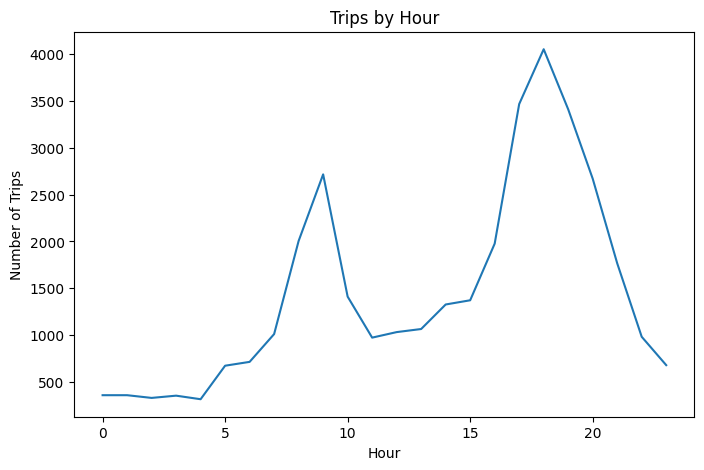

In [ ]:
#Exploratory data Analysis(EDA)
trip_hour = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.lineplot(x=trip_hour.index, y=trip_hour.values)

plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()


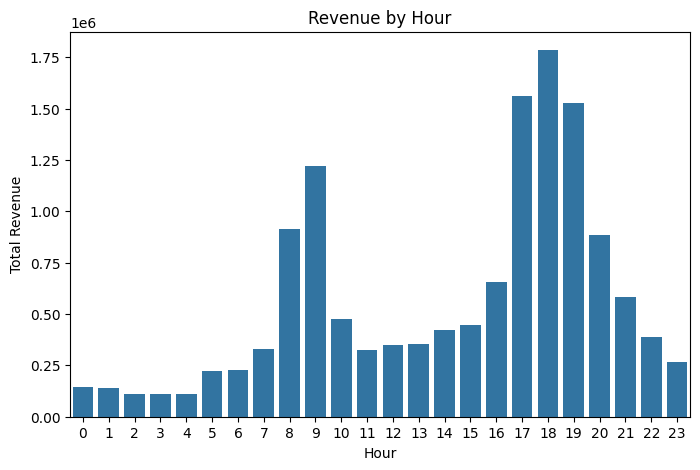

In [ ]:
#Revenue  By Hour

hourly_revenue = df.groupby('Hour')['Fare_Amount'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=hourly_revenue, x='Hour', y='Fare_Amount')

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Revenue")
plt.show()

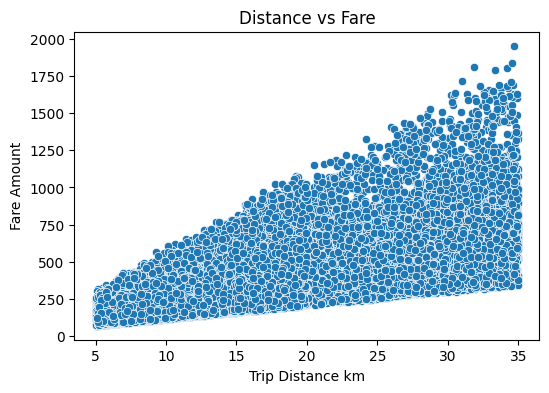

In [ ]:
#Distance Vs Fare

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='Trip_Distance_km',
    y='Fare_Amount'
)

plt.title("Distance vs Fare")
plt.xlabel("Trip Distance km")
plt.ylabel("Fare Amount")
plt.show()

In [ ]:
#Airport Vs City Fare
avg_fares = df.groupby('Is_Airport_Trip')['Fare_Amount'].mean()

print("Average Airport Fare:", avg_fares.get(True))
print("Average City Fare:", avg_fares.get(False))

Average Airport Fare: 535.7653952683208
Average City Fare: 289.40440622634367


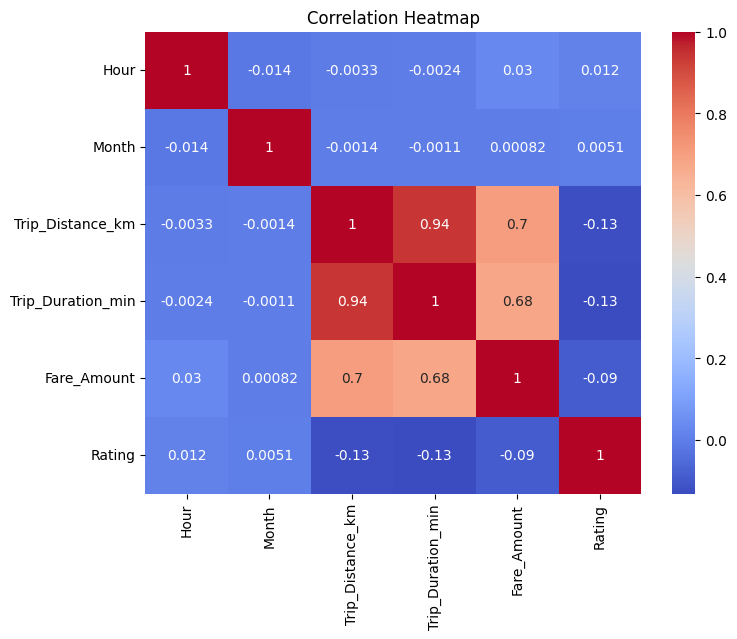

In [ ]:
#Correlation Heatmap

numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Bussiness Insight

# Peak Hour Demand
peak_hour = df['Hour'].value_counts().idxmax()
print(f"Peak trip demand occurs at hour: {peak_hour}")

# Peak Hour Revenue Share
peak_revenue = df[df['Hour'].isin([17, 18, 19])]['Fare_Amount'].sum()
total_revenue = df['Fare_Amount'].sum()
peak_revenue_share = (peak_revenue / total_revenue) * 100
print(f"Peak Hours Revenue Share (5 PM - 7 PM): {peak_revenue_share:.2f}%")

# Airport vs City Fare
avg_fares = df.groupby('Is_Airport_Trip')['Fare_Amount'].mean()

airport_fare = avg_fares.get(True, 0)
city_fare = avg_fares.get(False, 0)

print(f"Average Airport Trip Fare: ₹{airport_fare:.2f}")
print(f"Average City Trip Fare: ₹{city_fare:.2f}")


Peak trip demand occurs at hour: 18
Peak Hours Revenue Share (5 PM - 7 PM): 35.95%
Average Airport Trip Fare: ₹535.77
Average City Trip Fare: ₹289.40


In [ ]:
# Distance Impact on Fare
corr_distance_fare = df[['Trip_Distance_km','Fare_Amount']].corr().iloc[0,1]
print(f"Correlation between Distance and Fare: {corr_distance_fare:.2f}")

# Weekend Trip Pattern
weekend_trips = df['Is_Weekend'].value_counts()

print("\nWeekend vs Weekday Trips:")
print(weekend_trips)

Correlation between Distance and Fare: 0.70

Weekend vs Weekday Trips:
Is_Weekend
False    24975
True     10025
Name: count, dtype: int64


In [ ]:
#Machine Learning-Fare rediction

features = [
'Trip_Distance_km','Trip_Duration_min','Vehicle_Type','Pickup_Location','Dropoff_Location','Hour',
'Is_Weekend'
]

ml_df = df[features + ['Fare_Amount']].copy()

In [ ]:
# Encode categorical Variable

le = LabelEncoder()
categorical_cols = ['Vehicle_Type','Pickup_Location','Dropoff_Location'
]

for col in categorical_cols:
    ml_df[col] = le.fit_transform(ml_df[col])

In [ ]:
#train Test Split

X = ml_df.drop('Fare_Amount', axis=1)
y = ml_df['Fare_Amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Train Model

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#Model Evaluation
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 37.41423132346108
R2 Score: 0.9721779565946104


             Feature  Importance
0   Trip_Distance_km    0.520887
2       Vehicle_Type    0.381887
5               Hour    0.078382
1  Trip_Duration_min    0.013352
3    Pickup_Location    0.002313
4   Dropoff_Location    0.002218
6         Is_Weekend    0.000961


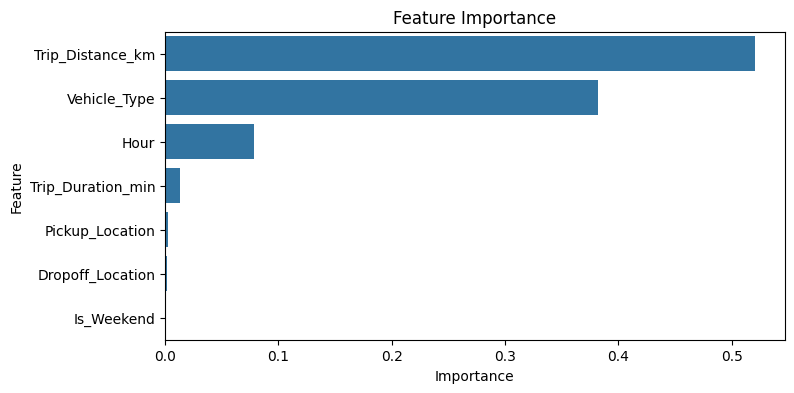

In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
'Feature': X.columns,
'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance")
plt.show()

In [ ]:
# ==========================================
# STEP 10: EXPORT DATA
# ==========================================

df.to_csv("Uber_Cleaned_For_PowerBI.csv", index=False)

print("File exported successfully")

File exported successfully


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("uber_trips_data.csv")

# Create pivot table
summary = df.pivot_table(index='Vehicle_Type',
                         values='Fare_Amount',
                         aggfunc='mean')

# Export Excel report
with pd.ExcelWriter('Uber_Report.xlsx') as writer:
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    summary.to_excel(writer, sheet_name='Summary')

print("Excel Report Created!")

Excel Report Created!
